## Đồ Án 1

## Import data
Lưu ý: Tọa độ thành phố Hồ Chí Minh chỉ từ 10.38-11.10 vĩ độ bắc và 106.22-106.56 kinh độ đông

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import numpy as np



In [2]:
df = pd.read_csv("data.csv")
# df = df[:36000]

In [3]:
df.shape

(45326, 11)

In [4]:
# Lọc trùng lặp
df = df.drop_duplicates()
df.shape

(19657, 11)

In [5]:
# Bởi vì data tạo độ lúc crawl có nhân 1 tỷ nên cần chia lại cho đúng
df["tọa độ x"], df["tọa độ y"] = df["tọa độ x"]/1000000000, df["tọa độ y"]/1000000000
df.drop(columns=["giá"], inplace=True)

Thêm khoảng cách từ vị trí bất động sản để trung tâm thành phố, là vị trí của nhà thờ Đức Bà (lat:10.7769, lon:106.7009)

In [6]:
lat = 10.7769
lon = 106.7009

def haversine(lat1, lon1, lat2, lon2):
    R = 6371

    lat1, lon1, lat2, lon2 = map(
        np.radians, [lat1, lon1, lat2, lon2]
    )

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + \
        np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2

    c = 2*np.arcsin(np.sqrt(a))

    return R*c

df["cách trung tâm"] = haversine(
    df["tọa độ x"],
    df["tọa độ y"],
    lat,
    lon
)

In [7]:
df.head()

,loại nhà đất,địa chỉ,diện tích,giá/m2,mặt tiền,phòng ngủ,pháp lý,tọa độ x,tọa độ y,số tầng,cách trung tâm
0,0,23,88.8,73.09,NaN,2.0,NaN,10.803385,106.617524,NaN,9.571355
1,2,5,47.0,92.55,4.0,2.0,1.0,10.842744,106.642948,2.0,9.678252
2,7,21,216.0,82.87,12.0,NaN,1.0,10.842596,106.717190,NaN,7.518595
3,0,18,65.0,76.92,NaN,2.0,2.0,10.750351,106.723175,NaN,3.825693
4,4,0,128.0,58.59,6.0,5.0,1.0,10.669288,106.613250,3.0,15.325910


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19657 entries, 0 to 45318
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   loại nhà đất    19657 non-null  int64  
 1   địa chỉ         19657 non-null  int64  
 2   diện tích       19657 non-null  float64
 3   giá/m2          19657 non-null  float64
 4   mặt tiền        11702 non-null  float64
 5   phòng ngủ       13441 non-null  float64
 6   pháp lý         16183 non-null  float64
 7   tọa độ x        19657 non-null  float64
 8   tọa độ y        19657 non-null  float64
 9   số tầng         9140 non-null   float64
 10  cách trung tâm  19657 non-null  float64
dtypes: float64(9), int64(2)
memory usage: 1.8 MB


In [9]:
df.describe()

,loại nhà đất,địa chỉ,diện tích,giá/m2,mặt tiền,phòng ngủ,pháp lý,tọa độ x,tọa độ y,số tầng,cách trung tâm
count,19657.000000,19657.000000,19657.000000,19657.000000,11702.000000,13441.000000,16183.000000,19657.000000,19657.000000,9140.000000,19657.000000
mean,2.503739,13.083278,115.648229,144.545157,7.113779,3.818838,1.117098,11.002385,106.623598,3.516849,38.051574
std,2.199918,7.182029,108.329786,266.919645,17.552353,4.520653,0.321547,1.495223,2.463959,1.698477,315.585679
min,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.023074
25%,0.000000,7.000000,60.000000,70.000000,4.000000,2.000000,1.000000,10.762763,106.653595,2.000000,4.274043
50%,2.000000,13.000000,82.000000,108.360000,5.000000,3.000000,1.000000,10.793528,106.697066,3.000000,7.092201
75%,4.000000,20.000000,125.000000,171.430000,7.000000,4.000000,1.000000,10.826981,106.736410,4.000000,10.299434
max,7.000000,23.000000,996.000000,23000.000000,764.000000,115.000000,2.000000,25.457272,106.975829,25.000000,11830.911635


In [10]:
REAL_ESTATE_ = {
    'căn hộ chung cư': 0,
    'chung cư mini, căn hộ dịch vụ': 1, # X
    'nhà riêng': 2, 
    'nhà biệt thự, liền kề':3,
    'nhà mặt phố': 4,
    'shophouse, nhà phố thương mại': 5,# X
    'đất nền dự án': 6, # X
    'bán đất': 7,
    'condotel': 8, # X
    'kho nhà xưởng': 9 # X
}


ADDRESS_ = {
    'bình chánh':0, 
    'bình tân':1,  #
    'bình thạnh':2, #
    'cần giờ':3,
    'củ chi':4,
    'gò vấp':5,#
    'hóc môn':6,
    'nhà bè':7,
    'phú nhuận':8,
    'quận 1':9,
    'quận 10':10,
    'quận 11':11,
    'quận 12':12,#
    'quận 2':13,#
    'quận 3':14,
    'quận 4':15,
    'quận 5':16,
    'quận 6':17,
    'quận 7':18,#
    'quận 8':19,
    'quận 9':20,#
    'thủ đức':21,#
    'tân bình':22,#
    'tân phú':23 #
}

In [11]:
# print(df["loại nhà đất"].value_counts())
for i in df.value_counts("loại nhà đất").index:
    for j in REAL_ESTATE_:
        if i == REAL_ESTATE_[j]:
            print(f"{j}: {df.value_counts('loại nhà đất')[i]}") 

nhà riêng: 6362
căn hộ chung cư: 5732
nhà mặt phố: 3563
bán đất: 1998
nhà biệt thự, liền kề: 1200
đất nền dự án: 656
shophouse, nhà phố thương mại: 143
chung cư mini, căn hộ dịch vụ: 3


In [12]:
df.describe()

,loại nhà đất,địa chỉ,diện tích,giá/m2,mặt tiền,phòng ngủ,pháp lý,tọa độ x,tọa độ y,số tầng,cách trung tâm
count,19657.000000,19657.000000,19657.000000,19657.000000,11702.000000,13441.000000,16183.000000,19657.000000,19657.000000,9140.000000,19657.000000
mean,2.503739,13.083278,115.648229,144.545157,7.113779,3.818838,1.117098,11.002385,106.623598,3.516849,38.051574
std,2.199918,7.182029,108.329786,266.919645,17.552353,4.520653,0.321547,1.495223,2.463959,1.698477,315.585679
min,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.023074
25%,0.000000,7.000000,60.000000,70.000000,4.000000,2.000000,1.000000,10.762763,106.653595,2.000000,4.274043
50%,2.000000,13.000000,82.000000,108.360000,5.000000,3.000000,1.000000,10.793528,106.697066,3.000000,7.092201
75%,4.000000,20.000000,125.000000,171.430000,7.000000,4.000000,1.000000,10.826981,106.736410,4.000000,10.299434
max,7.000000,23.000000,996.000000,23000.000000,764.000000,115.000000,2.000000,25.457272,106.975829,25.000000,11830.911635


## Loại bỏ những data không cần thết

In [13]:
# Ta thấy lượng data của "shophoue, nhà phố thương mại" 
# và "chung cư mini, căn hộ dịch vụ" khá ít. 
# Ta quyết định bỏ đi những data này
mask_remove_real_estate = (
    (df["loại nhà đất"] == REAL_ESTATE_["shophouse, nhà phố thương mại"])
    | (df["loại nhà đất"] == REAL_ESTATE_["chung cư mini, căn hộ dịch vụ"])
    | (df["loại nhà đất"] == REAL_ESTATE_["đất nền dự án"])
)
df.drop(df[mask_remove_real_estate].index, inplace=True)


# Khu vực thành phố hồ chí minh chỉ từ 10.38-11.10 vĩ độ bắc và 106.22-106.56 kinh độ đông.
# Loại bỏ những data ngoài khu vực
remove_out_of_city = (
    (df["tọa độ y"] < 106.1) | (df["tọa độ y"] > 106.8)
    | (df["tọa độ x"] < 10.38) | (df["tọa độ x"] > 11.10)
)
df.drop(df[remove_out_of_city].index, inplace=True)


# Hầu hết các nhà đều có sổ đỏ, sổ hồng. Với các nhà chỉ ở dạng 
# hợp đồng rất hạn chế nên có thể bỏ các data có dữ liệu này
df.drop(df[df["pháp lý"] == 2].index, inplace=True)
df.drop(df[df["pháp lý"].isna()].index, inplace=True)
df.drop(columns=["pháp lý"], inplace=True)

In [14]:
df.describe()

,loại nhà đất,địa chỉ,diện tích,giá/m2,mặt tiền,phòng ngủ,tọa độ x,tọa độ y,số tầng,cách trung tâm
count,12960.000000,12960.000000,12960.000000,12960.000000,9397.000000,9313.000000,12960.000000,12960.000000,7681.000000,12960.000000
mean,2.728472,12.489198,114.690664,148.084755,6.732673,4.269623,10.793560,106.687203,3.444343,7.465589
std,2.053221,7.361031,110.598220,141.276580,12.801546,4.792158,0.053964,0.056367,1.609641,4.882629
min,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,10.533189,106.360811,1.000000,0.023074
25%,2.000000,6.000000,60.000000,78.120000,4.000000,2.000000,10.760870,106.649297,2.000000,4.078444
50%,2.000000,13.000000,81.000000,115.380000,5.000000,3.000000,10.793165,106.689630,3.000000,6.758367
75%,4.000000,20.000000,124.000000,178.000000,7.000000,4.000000,10.828159,106.726031,4.000000,9.793448
max,7.000000,23.000000,996.000000,6300.000000,737.000000,115.000000,11.092275,106.799985,25.000000,47.974788


## Plot dữ liệu

In [15]:
from pathlib import Path
IMAGES_PATH = Path() / "images" / "end_to_end_project"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

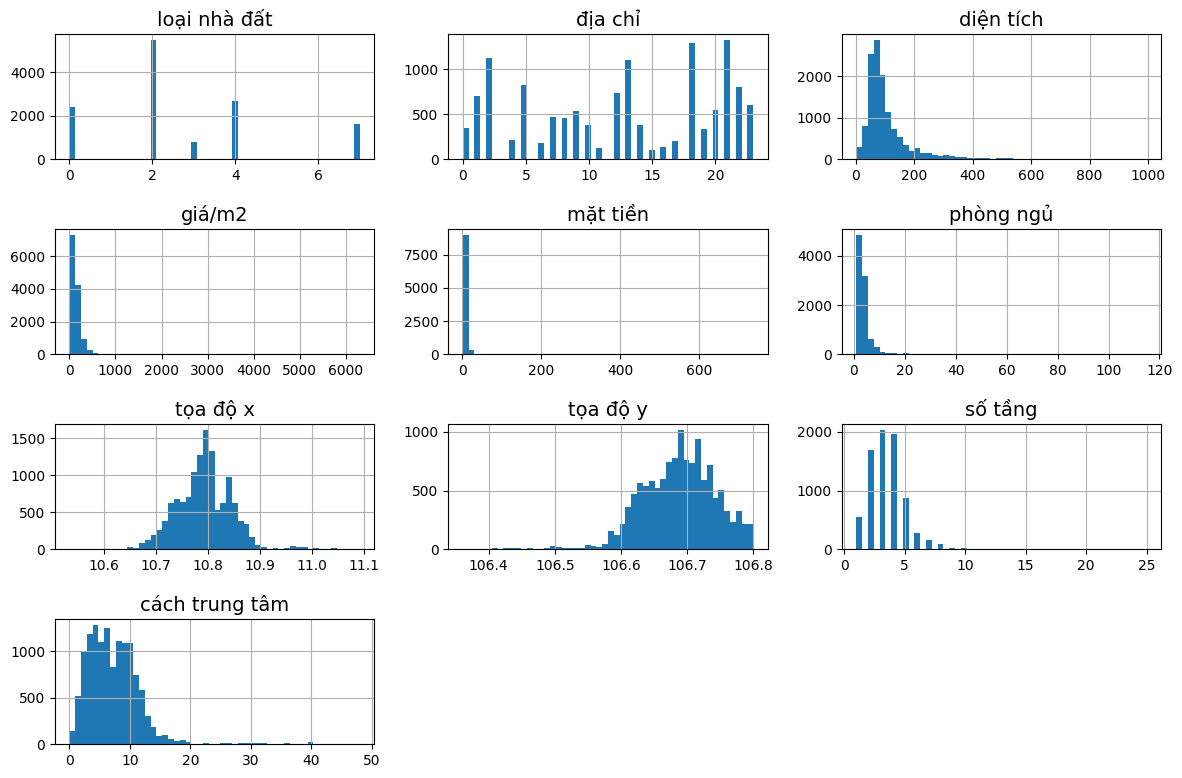

In [16]:
import matplotlib.pyplot as plt

# extra code – the next 5 lines define the default font sizes
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

df.hist(bins=50, figsize=(12, 8))
save_fig("attribute_histogram_plots")  # extra code
plt.show()

## Create data test

Giữ nguyên tỷ lệ phân bố của một biến quan trọng
trong cả train và test

In [17]:
np.random.seed(42)

In [18]:
df["distance_center_cat"] = pd.cut(df["cách trung tâm"],
                                    bins=[0., 5., 10., 15., np.inf],
                                    labels=[1, 2, 3, 4])

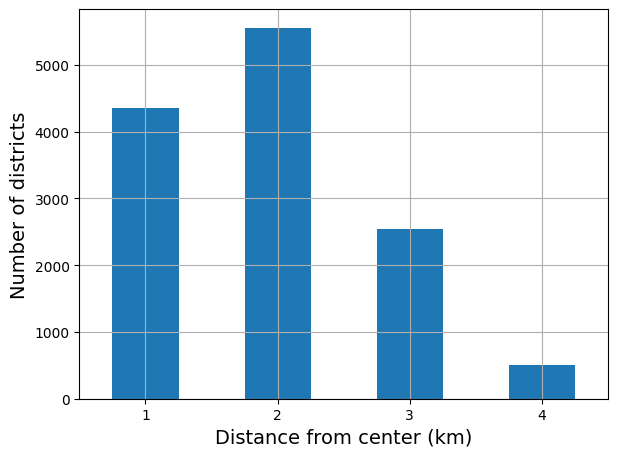

In [19]:
df["distance_center_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.xlabel("Distance from center (km)")
plt.ylabel("Number of districts")
save_fig("housing_distance_cat_bar_plot")  # extra code
plt.show()

In [20]:
from sklearn.model_selection import StratifiedShuffleSplit

splitter = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
strat_splits = []
for train_index, test_index in splitter.split(df, df["distance_center_cat"]):
    strat_train_set_n = df.iloc[train_index]
    strat_test_set_n = df.iloc[test_index]
    strat_splits.append([strat_train_set_n, strat_test_set_n])

In [21]:
strat_train_set, strat_test_set = strat_splits[0]

In [22]:
df["distance_center_cat"].value_counts() / len(df)

distance_center_cat
2    0.428858
1    0.336343
3    0.195910
4    0.038889
Name: count, dtype: float64

In [23]:
strat_train_set["distance_center_cat"].value_counts() / len(strat_train_set)

distance_center_cat
2    0.428916
1    0.336323
3    0.195891
4    0.038870
Name: count, dtype: float64

In [24]:
strat_test_set["distance_center_cat"].value_counts() / len(strat_test_set)

distance_center_cat
2    0.428627
1    0.336420
3    0.195988
4    0.038966
Name: count, dtype: float64

In [25]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("distance_center_cat", axis=1, inplace=True)

C:\Users\huy\AppData\Local\Temp\ipykernel_8784\3306667349.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  set_.drop("distance_center_cat", axis=1, inplace=True)
C:\Users\huy\AppData\Local\Temp\ipykernel_8784\3306667349.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  set_.drop("distance_center_cat", axis=1, inplace=True)


In [26]:
train_set = strat_train_set
test_set = strat_test_set

In [27]:
print(f"train set shape: {train_set.shape}")
print(f"test set shape: {test_set.shape}")

train set shape: (10368, 10)
test set shape: (2592, 10)


# Discover and Visualize the Data to Gain Insights

In [28]:
housing = train_set.copy()

## Visualizing Geographical Data

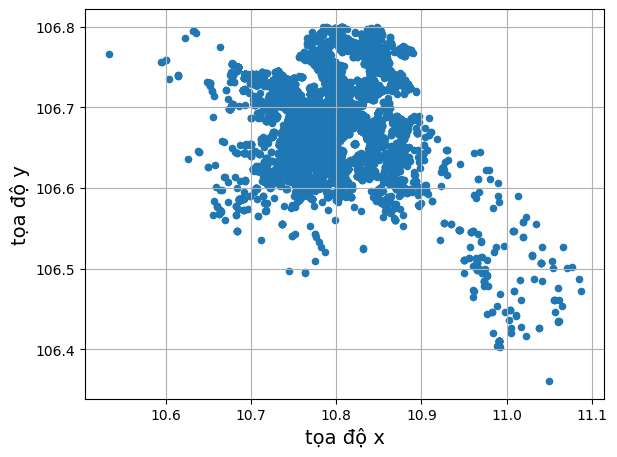

In [29]:
housing.plot(kind="scatter", x="tọa độ x", y="tọa độ y", grid=True)
save_fig("bad_visualization_plot")  # extra code
plt.show()

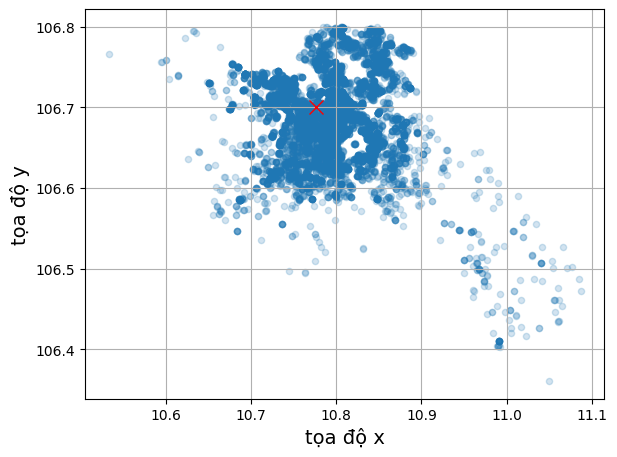

In [30]:
housing.plot(kind="scatter", x="tọa độ x", y="tọa độ y", grid=True, alpha=0.2)
# vẽ dấu x biểu thị trung tâm thành phố
plt.plot(lat, lon, "x", color="red", markersize=10, label="Trung tâm thành phố")
save_fig("better_visualization_plot")  # extra code
plt.show()

# Biểu đồ tương quan các feature

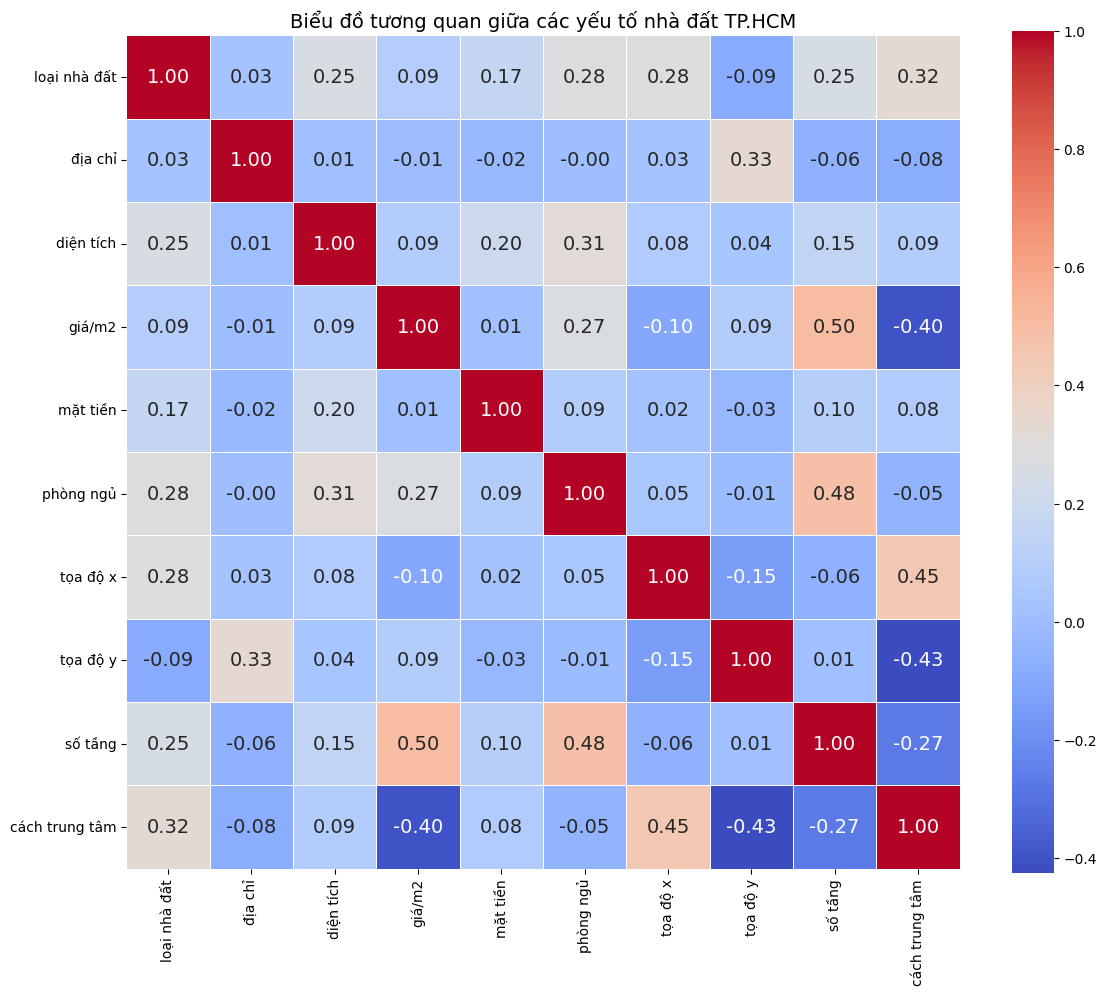

In [31]:
import seaborn as sns

corr_matrix = housing.corr(numeric_only=True)

# 2. Thiết lập kích thước biểu đồ
plt.figure(figsize=(12, 10))

# 3. Vẽ heatmap
sns.heatmap(corr_matrix, 
            annot=True,       # Hiển thị số liệu trên từng ô
            fmt=".2f",        # Làm tròn 2 chữ số thập phân
            cmap='coolwarm',  # Màu sắc (Đỏ: tương quan thuận, Xanh: tương quan nghịch)
            linewidths=0.5,   # Khoảng cách giữa các ô
            square=True)      # Giữ các ô là hình vuông

plt.title('Biểu đồ tương quan giữa các yếu tố nhà đất TP.HCM')
save_fig("correlation_heatmap")  # extra code
plt.show()

In [32]:
corr_matrix = housing.corr(numeric_only=True)

In [33]:
corr_matrix["giá/m2"].sort_values(ascending=False)

giá/m2            1.000000
số tầng           0.500729
phòng ngủ         0.267920
loại nhà đất      0.094449
tọa độ y          0.088414
diện tích         0.085449
mặt tiền          0.009339
địa chỉ          -0.007212
tọa độ x         -0.102227
cách trung tâm   -0.401678
Name: giá/m2, dtype: float64

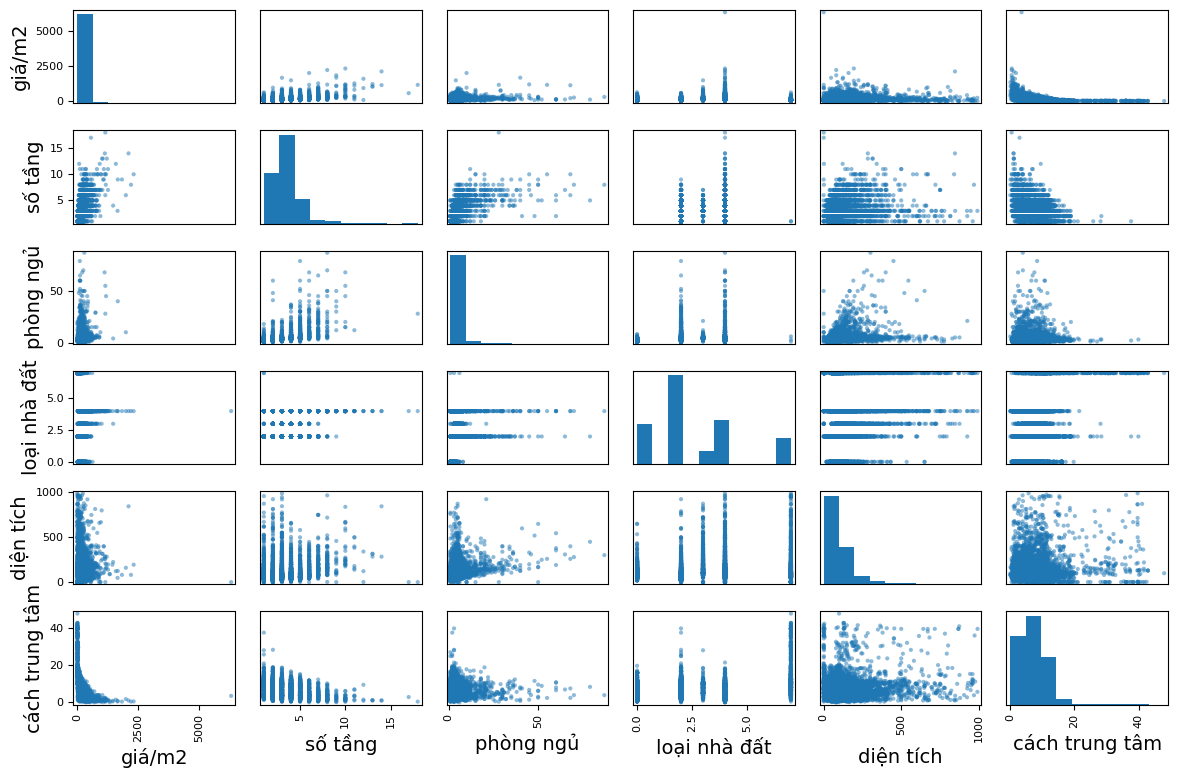

In [34]:
from pandas.plotting import scatter_matrix

attributes = ["giá/m2", "số tầng", "phòng ngủ", "loại nhà đất", "diện tích", "cách trung tâm"]

scatter_matrix(housing[attributes], figsize=(12, 8))
save_fig("scatter_matrix_plot")  # extra code
plt.show()  

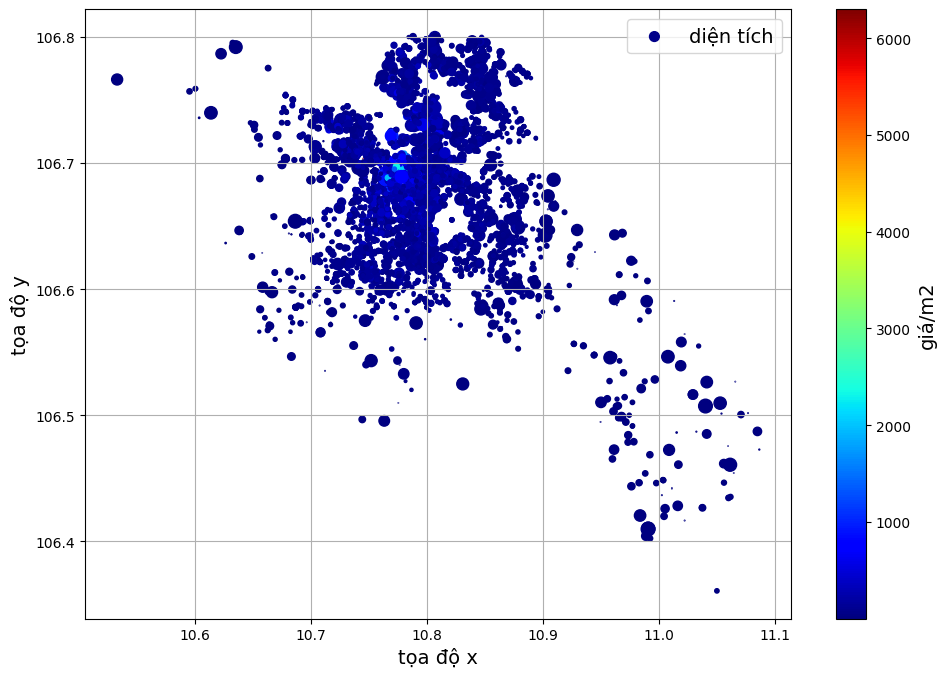

In [35]:
housing.plot(kind="scatter", x="tọa độ x", y="tọa độ y", grid=True,
             s=housing["diện tích"]/10 , label="diện tích",
             c="giá/m2", cmap="jet", colorbar=True,
             legend=True, sharex=False, figsize=(10, 7))
save_fig("housing_prices_scatterplot")  # extra code
plt.show()

## Data cleaning


In [36]:
housing.describe()

,loại nhà đất,địa chỉ,diện tích,giá/m2,mặt tiền,phòng ngủ,tọa độ x,tọa độ y,số tầng,cách trung tâm
count,10368.000000,10368.000000,10368.000000,10368.000000,7504.000000,7465.000000,10368.000000,10368.000000,6140.000000,10368.000000
mean,2.718654,12.505498,114.833111,147.852096,6.663490,4.238312,10.793471,106.687600,3.429805,7.459045
std,2.055521,7.384699,110.163061,143.639924,11.815294,4.671110,0.053911,0.056403,1.595765,4.873459
min,0.000000,0.000000,1.000000,1.020000,1.000000,1.000000,10.533189,106.360811,1.000000,0.023074
25%,2.000000,5.000000,60.000000,77.670000,4.000000,2.000000,10.760506,106.649421,2.000000,4.081015
50%,2.000000,13.000000,81.000000,114.670000,5.000000,3.000000,10.793253,106.689986,3.000000,6.746158
75%,4.000000,20.000000,125.000000,177.420000,7.000000,4.000000,10.827887,106.726240,4.000000,9.795835
max,7.000000,23.000000,991.000000,6300.000000,737.000000,87.000000,11.086623,106.799985,18.000000,47.974788


In [37]:
def set_median_none_in_column(df, column_names):
    for column_name in column_names:
        median_value = df[column_name].median()
        df[column_name] = df[column_name].fillna(median_value)

set_median_none_in_column(housing, ["số tầng", "phòng ngủ", "mặt tiền"])


In [38]:
housing.describe()

,loại nhà đất,địa chỉ,diện tích,giá/m2,mặt tiền,phòng ngủ,tọa độ x,tọa độ y,số tầng,cách trung tâm
count,10368.000000,10368.000000,10368.000000,10368.000000,10368.000000,10368.000000,10368.000000,10368.000000,10368.000000,10368.000000
mean,2.718654,12.505498,114.833111,147.852096,6.203977,3.891590,10.793471,106.687600,3.254533,7.459045
std,2.055521,7.384699,110.163061,143.639924,10.079091,4.002316,0.053911,0.056403,1.246014,4.873459
min,0.000000,0.000000,1.000000,1.020000,1.000000,1.000000,10.533189,106.360811,1.000000,0.023074
25%,2.000000,5.000000,60.000000,77.670000,4.000000,3.000000,10.760506,106.649421,3.000000,4.081015
50%,2.000000,13.000000,81.000000,114.670000,5.000000,3.000000,10.793253,106.689986,3.000000,6.746158
75%,4.000000,20.000000,125.000000,177.420000,5.500000,4.000000,10.827887,106.726240,4.000000,9.795835
max,7.000000,23.000000,991.000000,6300.000000,737.000000,87.000000,11.086623,106.799985,18.000000,47.974788


# Remove oulier

Cách 1: sử dụng iqr

In [39]:
def up_low_val_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

def remove_outliers_columns(df, columns):
    iqrs = []
    for column in columns:
        lower_bound, upper_bound = up_low_val_iqr(df, column)
        iqrs.append((lower_bound, upper_bound))
    for i, column in enumerate(columns):
        lower_bound, upper_bound = iqrs[i]
        df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df



In [40]:
housing_1 = housing.copy()

columns_to_remove_outliers = ["diện tích", "giá/m2", "số tầng", "phòng ngủ", "mặt tiền"]
housing_1 = remove_outliers_columns(housing_1, columns_to_remove_outliers)

housing_1.describe()

,loại nhà đất,địa chỉ,diện tích,giá/m2,mặt tiền,phòng ngủ,tọa độ x,tọa độ y,số tầng,cách trung tâm
count,6858.000000,6858.000000,6858.000000,6858.000000,6858.000000,6858.000000,6858.000000,6858.000000,6858.000000,6858.000000
mean,2.379848,12.594780,80.970555,118.414192,4.566312,3.130505,10.791324,106.687922,3.097404,7.587189
std,2.100560,7.489031,36.969557,62.006224,1.006163,0.876358,0.053732,0.055570,0.704258,4.421109
min,0.000000,0.000000,1.000000,1.300000,1.800000,2.000000,10.595106,106.360811,2.000000,0.243980
25%,0.000000,5.000000,56.000000,73.390000,4.000000,3.000000,10.751812,106.647904,3.000000,4.398282
50%,2.000000,13.000000,74.000000,105.880000,5.000000,3.000000,10.792540,106.689886,3.000000,7.110389
75%,3.000000,20.000000,100.000000,151.160000,5.000000,4.000000,10.828777,106.727276,3.000000,9.883833
max,7.000000,23.000000,222.000000,324.320000,7.750000,5.000000,11.086623,106.799913,5.000000,47.974788


In [41]:
housing_1.shape

(6858, 10)

Cách 2: Loại bỏ theo logic thực tế

In [80]:
housing.shape

(10368, 10)

In [78]:
housing_2 = housing.copy()
housing_2= housing_2[housing_2["phòng ngủ"] < 11]
housing_2 = housing_2[housing_2["mặt tiền"] <= 30]
housing_2 = housing_2[housing_2["giá/m2"] <= 500]
housing_2 = housing_2[housing_2["diện tích"] <= 500]
housing_2 = housing_2[(housing_2["diện tích"] >= 15)]



In [79]:
housing_2.describe()

,loại nhà đất,địa chỉ,diện tích,giá/m2,mặt tiền,phòng ngủ,tọa độ x,tọa độ y,số tầng,cách trung tâm
count,9497.000000,9497.000000,9497.000000,9497.000000,9497.000000,9497.000000,9497.000000,9497.000000,9497.000000,9497.000000
mean,2.587659,12.623776,102.845821,134.590634,5.384509,3.363483,10.792401,106.688673,3.157945,7.402040
std,2.030913,7.385640,73.767921,83.608732,2.904091,1.413665,0.052141,0.055027,1.057781,4.438153
min,0.000000,0.000000,15.000000,2.140000,1.000000,1.000000,10.595573,106.360811,1.000000,0.023074
25%,2.000000,6.000000,60.000000,78.000000,4.000000,3.000000,10.758183,106.649584,3.000000,4.200536
50%,2.000000,13.000000,80.000000,113.180000,5.000000,3.000000,10.793129,106.690163,3.000000,6.868058
75%,4.000000,20.000000,117.100000,170.830000,5.000000,4.000000,10.827621,106.727219,3.000000,9.780759
max,7.000000,23.000000,500.000000,500.000000,30.000000,10.000000,11.085016,106.799985,11.000000,47.974788


Nhìn vào mô tả dữ liệu từ 2 cách, ta thấy:
- Cách 1 tuy cho ra các dữ liệu sạch, và đẹp mắt nhưng lại trở nên quá nhỏ. Thực tế ở Tp.HCM có nhiều biệt thự, nhà riêng lớn vẫn rao bán.
- Cách 2, giữ lại được nhiều dữ liệu, tuy nhiên vẫn còn nhiều outlier.


Chọn cách 2 vì:
- giữ nhiều dữ liệu hơn
- không loại dữ liệu hợp lý
- model học được nhiều pattern hơn

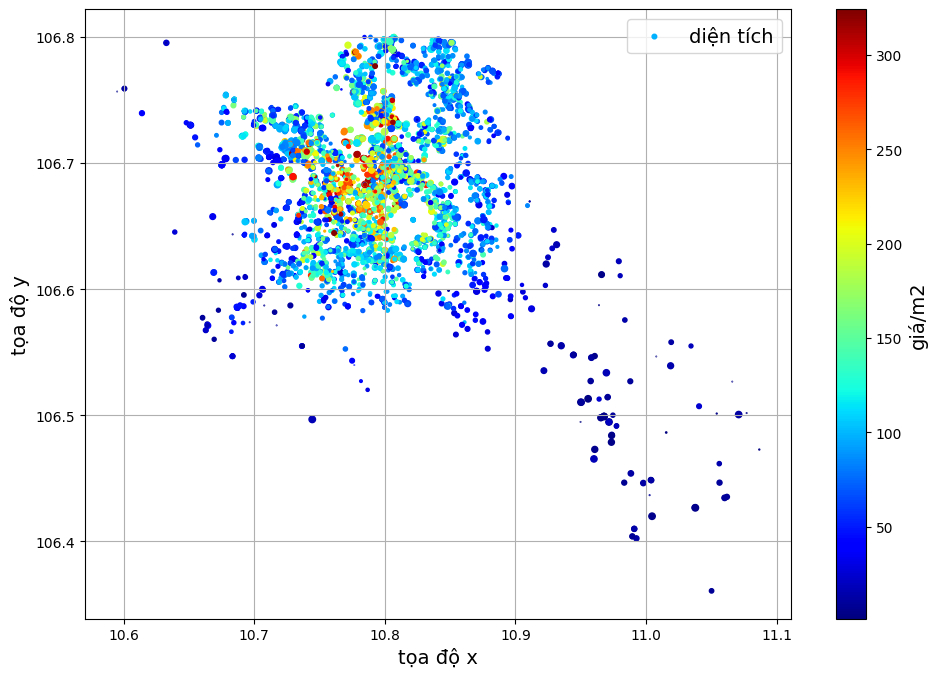

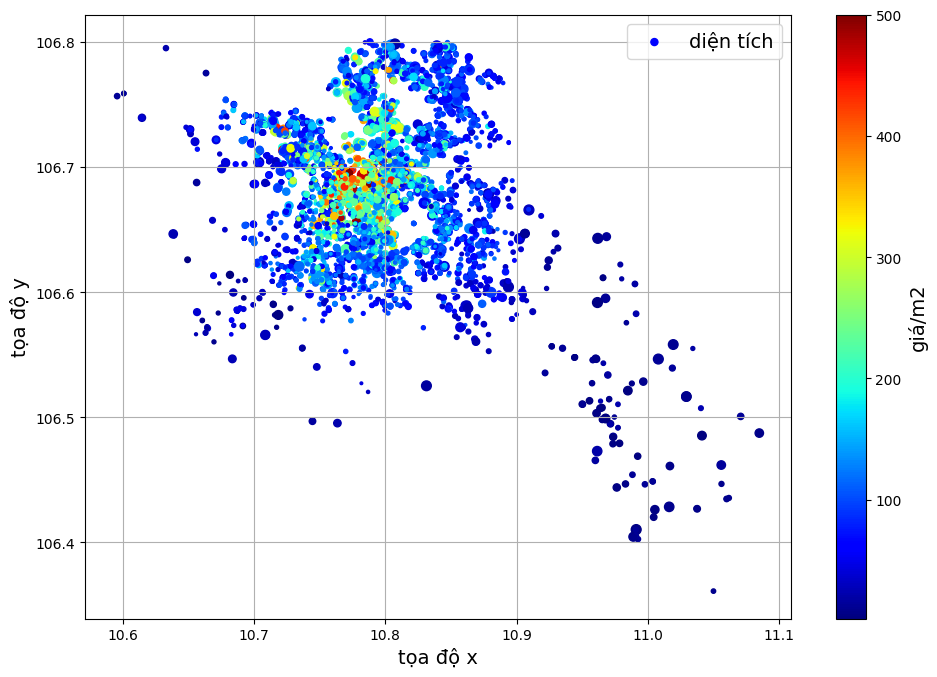

In [81]:
housing_1.plot(kind="scatter", x="tọa độ x", y="tọa độ y", grid=True,
             s=housing_1["diện tích"]/10 , label="diện tích",
             c="giá/m2", cmap="jet", colorbar=True,
             legend=True, sharex=False, figsize=(10, 7))
save_fig("housing_1_prices_scatterplot")  # extra code

housing_2.plot(kind="scatter", x="tọa độ x", y="tọa độ y", grid=True,
             s=housing_2["diện tích"]/10 , label="diện tích",
             c="giá/m2", cmap="jet", colorbar=True,
             legend=True, sharex=False, figsize=(10, 7))
save_fig("housing_2_prices_scatterplot")  # extra code

plt.show()




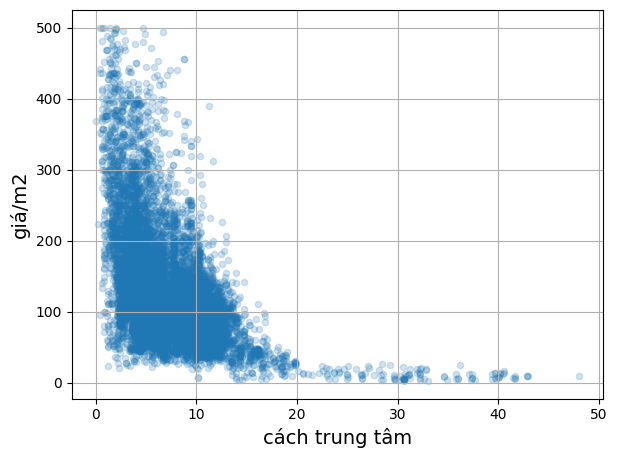

In [45]:
housing_2.plot(kind="scatter", x="cách trung tâm", y="giá/m2", grid=True, alpha=0.2)
save_fig("distance_center_vs_price_plot")  # extra code
plt.show()

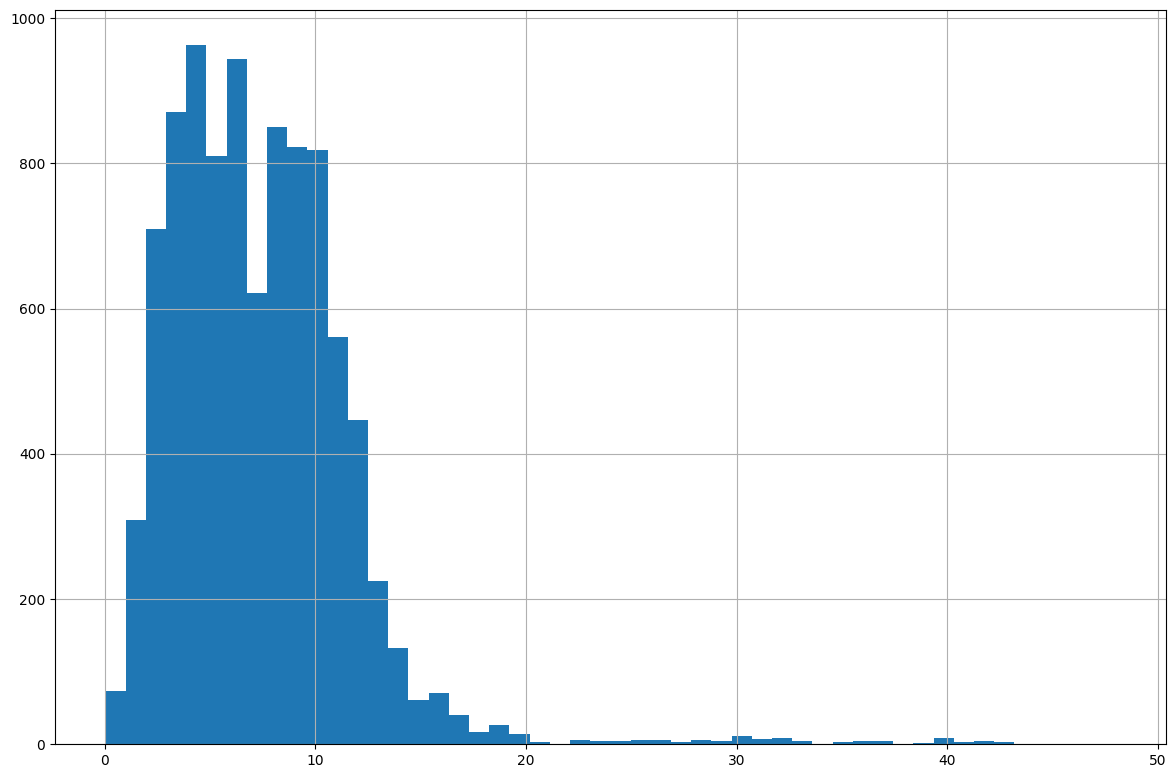

In [46]:
housing_2["cách trung tâm"].hist(bins=50, figsize=(12, 8))
save_fig("distance_center_histogram")  # extra code

data của khoảng cách tới trung tâm hơi lệch phải, ta sử dụng hàm log để tránh bị ảnh hưởng bởi outlier

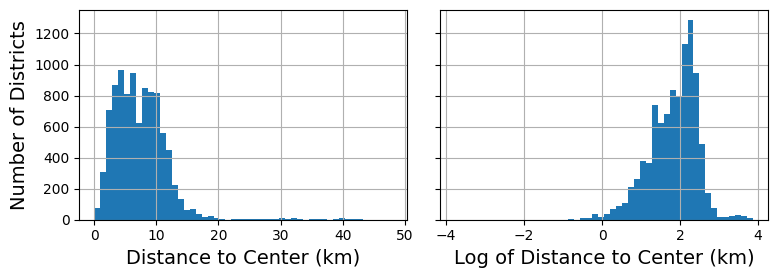

In [47]:
fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
housing_2["cách trung tâm"].hist(ax=axs[0], bins=50)
housing_2["cách trung tâm"].apply(np.log).hist(ax=axs[1], bins=50)
axs[0].set_xlabel("Distance to Center (km)")
axs[1].set_xlabel("Log of Distance to Center (km)")
axs[0].set_ylabel("Number of Districts")
save_fig("long_distance_center_plot")
plt.show()

Hàm log với distance to center không có quá nhiều thay đổi, ta quyết định sử dụng data gốc

## Giá trung bình theo quận

In [48]:
housing_test = housing_2.copy()
housing_test["district_mean_area"] = housing_test.groupby("địa chỉ")["giá/m2"].transform("mean")
mean_area = housing_test[["địa chỉ", "district_mean_area"]]
mean_area.drop_duplicates(inplace=True)
mean_area.sort_values(by="district_mean_area", ascending=False, inplace=True)
# Kết hợp với tên quận để dễ nhìn
for i in ADDRESS_:
    if ADDRESS_[i] in mean_area["địa chỉ"].values:
        mean_area.loc[mean_area["địa chỉ"] == ADDRESS_[i], "địa chỉ"] = i

print(mean_area)


          địa chỉ  district_mean_area
28362      quận 1          284.340528
43439      quận 3          255.427714
22593     quận 10          223.769468
30620   phú nhuận          194.308629
6567       quận 5          185.183878
3526     tân bình          168.823669
36026  bình thạnh          156.388209
39238      quận 2          155.442916
43204     quận 11          154.709462
21566      quận 4          152.482821
28136      quận 7          128.152579
38420      gò vấp          128.008252
25469      quận 6          121.447785
3605      tân phú          117.038731
4462       quận 9          104.038825
30332      quận 8          103.893985
810       thủ đức          103.174182
35037    bình tân           96.801800
8255      quận 12           84.049709
2991       nhà bè           78.291813
39117  bình chánh           60.810879
27619     hóc môn           44.854000
5299      cần giờ           19.360000
2783       củ chi           11.419316


C:\Users\huy\AppData\Local\Temp\ipykernel_8784\1548478164.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_area.drop_duplicates(inplace=True)
C:\Users\huy\AppData\Local\Temp\ipykernel_8784\1548478164.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_area.sort_values(by="district_mean_area", ascending=False, inplace=True)
C:\Users\huy\AppData\Local\Temp\ipykernel_8784\1548478164.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'bình chánh' has dtype incompatible with int64, please explicitly cast to a compatible dtype fir

In [49]:
REAL_ESTATE_VAL = {
     0: 'căn hộ chung cư',
    1: 'chung cư mini, căn hộ dịch vụ', # X
    2: 'nhà riêng', 
    3: 'nhà biệt thự, liền kề',
    4: 'nhà mặt phố',
    5: 'shophouse, nhà phố thương mại', # X
    6: 'đất nền dự án', # X
    7: 'bán đất',
    8: 'condotel', # X
    9: 'kho nhà xưởng' # X
}


ADDRESS_VAL = {
    0: 'bình chánh',
    1: 'bình tân',
    2: 'bình thạnh',
    3: 'cần giờ',
    4: 'củ chi',
    5: 'gò vấp',
    6: 'hóc môn',
    7: 'nhà bè',
    8: 'phú nhuận',
    9: 'quận 1',
    10: 'quận 10',
    11: 'quận 11',
    12: 'quận 12',#
    13: 'quận 2',#
    14: 'quận 3',
    15: 'quận 4',
    16: 'quận 5',
    17: 'quận 6',
    18: 'quận 7',
    19: 'quận 8',
    20: 'quận 9',
    21: 'thủ đức',
    22: 'tân bình',
    23: 'tân phú'
}

In [50]:
# tạo mảng 2 chiều về giá trị trung bình của từng loại nhà đất theo từng quận
housing_test["type_district_mean_area"] = housing_test.groupby(["loại nhà đất", "địa chỉ"])["giá/m2"].transform("mean")
type_district_mean_area = housing_test[["loại nhà đất", "địa chỉ", "type_district_mean_area"]]
type_district_mean_area.drop_duplicates(inplace=True)   



C:\Users\huy\AppData\Local\Temp\ipykernel_8784\2789636472.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  type_district_mean_area.drop_duplicates(inplace=True)


In [51]:
type_district_mean_area["loại nhà đất"] = type_district_mean_area["loại nhà đất"].map(REAL_ESTATE_VAL)
type_district_mean_area["địa chỉ"] = type_district_mean_area["địa chỉ"].map(ADDRESS_VAL)
print(type_district_mean_area)

                loại nhà đất     địa chỉ  type_district_mean_area
35037        căn hộ chung cư    bình tân                53.248553
810                  bán đất     thủ đức                84.973495
36026        căn hộ chung cư  bình thạnh               103.436117
30332            nhà mặt phố      quận 8               161.979048
3271               nhà riêng     thủ đức               100.039417
...                      ...         ...                      ...
44665  nhà biệt thự, liền kề     hóc môn                49.440000
38555            nhà mặt phố      củ chi                11.000000
32357  nhà biệt thự, liền kề     tân phú                99.723333
6686                 bán đất      quận 3               240.256667
29034  nhà biệt thự, liền kề      quận 6                72.920000

[107 rows x 3 columns]


C:\Users\huy\AppData\Local\Temp\ipykernel_8784\997375264.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  type_district_mean_area["loại nhà đất"] = type_district_mean_area["loại nhà đất"].map(REAL_ESTATE_VAL)
C:\Users\huy\AppData\Local\Temp\ipykernel_8784\997375264.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  type_district_mean_area["địa chỉ"] = type_district_mean_area["địa chỉ"].map(ADDRESS_VAL)


In [52]:
pivot_table = type_district_mean_area.pivot_table(
    values="type_district_mean_area",
    index="địa chỉ",
    columns="loại nhà đất",
    aggfunc="mean"
)

pivot_table.round(2)

loại nhà đất,bán đất,căn hộ chung cư,"nhà biệt thự, liền kề",nhà mặt phố,nhà riêng
địa chỉ,,,,,
bình chánh,30.69,46.84,123.88,104.50,20.94
bình thạnh,124.52,103.44,172.70,248.74,149.33
bình tân,73.41,53.25,116.44,134.68,98.67
cần giờ,19.36,NaN,NaN,NaN,NaN
củ chi,10.93,NaN,NaN,11.00,18.12
gò vấp,95.22,53.12,209.88,171.92,125.20
hóc môn,34.56,NaN,49.44,57.21,50.61
nhà bè,47.03,56.44,116.15,99.74,88.86
phú nhuận,NaN,88.44,318.75,295.24,184.46


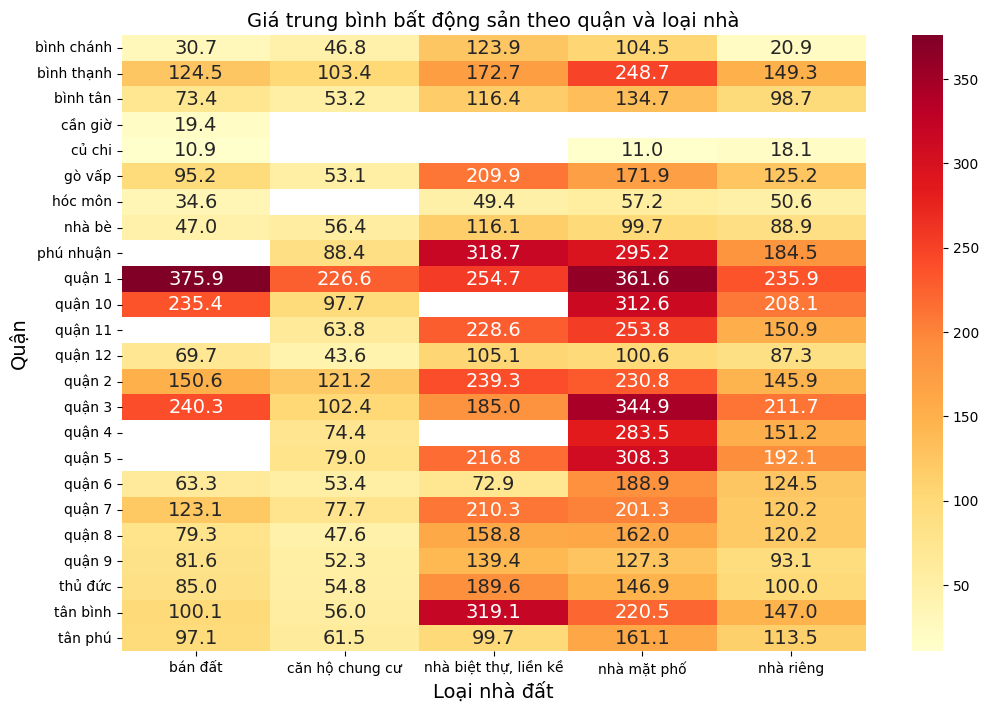

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(
    pivot_table,
    annot=True,
    cmap="YlOrRd",
    fmt=".1f"
)

plt.title("Giá trung bình bất động sản theo quận và loại nhà")
plt.xlabel("Loại nhà đất")
plt.ylabel("Quận")

plt.show()

In [54]:
# Hiển thị giá trị trung bình của từng loại nhà đất theo từng quận, hiện theo dạng bảng dễ nhìn
# địa chỉ là cột dọc, loại nhà đất là cột ngang
# Nếu cột nào không chứa dữ liệu thì sẽ hiển thị NaN
from tabulate import tabulate
type_district_mean_area["loại nhà đất"] = type_district_mean_area["loại nhà đất"].map(REAL_ESTATE_VAL)
type_district_mean_area["địa chỉ"] = type_district_mean_area["địa chỉ"].map(ADDRESS_VAL)
print(tabulate(type_district_mean_area, headers="keys", tablefmt="grid"))
# lưu bảng vào file csv
type_district_mean_area.to_csv("type_district_mean_area.csv", index=False)


+-------+----------------+-----------+---------------------------+
|       |   loại nhà đất |   địa chỉ |   type_district_mean_area |
+=======+================+===========+===========================+
| 35037 |            nan |       nan |                   53.2486 |
+-------+----------------+-----------+---------------------------+
|   810 |            nan |       nan |                   84.9735 |
+-------+----------------+-----------+---------------------------+
| 36026 |            nan |       nan |                  103.436  |
+-------+----------------+-----------+---------------------------+
| 30332 |            nan |       nan |                  161.979  |
+-------+----------------+-----------+---------------------------+
|  3271 |            nan |       nan |                  100.039  |
+-------+----------------+-----------+---------------------------+
|  3605 |            nan |       nan |                   61.481  |
+-------+----------------+-----------+------------------------

C:\Users\huy\AppData\Local\Temp\ipykernel_8784\2270891136.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  type_district_mean_area["loại nhà đất"] = type_district_mean_area["loại nhà đất"].map(REAL_ESTATE_VAL)
C:\Users\huy\AppData\Local\Temp\ipykernel_8784\2270891136.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  type_district_mean_area["địa chỉ"] = type_district_mean_area["địa chỉ"].map(ADDRESS_VAL)


# Nhận xét về giá/m2

Giá có vẻ đang có oulier khá lớn nên ta sẽ sử dụng hàm log để giảm sử ảnh hưởng của giá

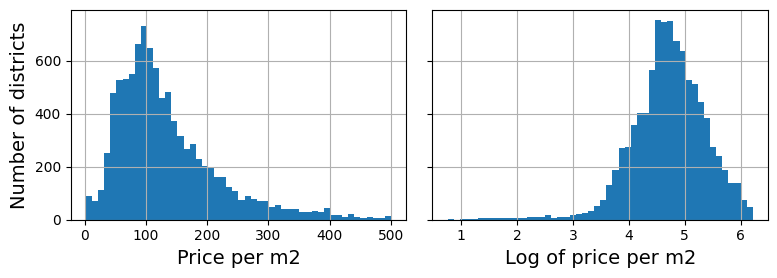

In [55]:
fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
housing_2["giá/m2"].hist(ax=axs[0], bins=50)
housing_2["giá/m2"].apply(np.log).hist(ax=axs[1], bins=50)
axs[0].set_xlabel("Price per m2")
axs[1].set_xlabel("Log of price per m2")
axs[0].set_ylabel("Number of districts")
save_fig("long_tail_plot")
plt.show()

## Nhận xét về diện tích

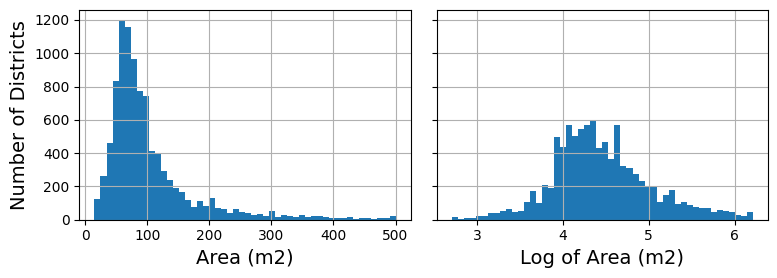

In [56]:
fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
housing_2["diện tích"].hist(ax=axs[0], bins=50)
housing_2["diện tích"].apply(np.log).hist(ax=axs[1], bins=50)
axs[0].set_xlabel("Area (m2)")
axs[1].set_xlabel("Log of Area (m2)")
axs[0].set_ylabel("Number of Districts")
save_fig("long_area_plot")
plt.show()

In [57]:
housing_2.describe()

,loại nhà đất,địa chỉ,diện tích,giá/m2,mặt tiền,phòng ngủ,tọa độ x,tọa độ y,số tầng,cách trung tâm
count,9497.000000,9497.000000,9497.000000,9497.000000,9497.000000,9497.000000,9497.000000,9497.000000,9497.000000,9497.000000
mean,2.587659,12.623776,102.845821,134.590634,5.384509,3.363483,10.792401,106.688673,3.157945,7.402040
std,2.030913,7.385640,73.767921,83.608732,2.904091,1.413665,0.052141,0.055027,1.057781,4.438153
min,0.000000,0.000000,15.000000,2.140000,1.000000,1.000000,10.595573,106.360811,1.000000,0.023074
25%,2.000000,6.000000,60.000000,78.000000,4.000000,3.000000,10.758183,106.649584,3.000000,4.200536
50%,2.000000,13.000000,80.000000,113.180000,5.000000,3.000000,10.793129,106.690163,3.000000,6.868058
75%,4.000000,20.000000,117.100000,170.830000,5.000000,4.000000,10.827621,106.727219,3.000000,9.780759
max,7.000000,23.000000,500.000000,500.000000,30.000000,10.000000,11.085016,106.799985,11.000000,47.974788


## Train model

6️⃣ Một cải tiến rất đáng làm

Dataset của bạn có tọa độ.
Có thể thêm feature:

housing_2["area_density"] = housing_2["diện tích"] / housing_2["phòng ngủ"]

Hoặc:

housing_2["frontage_ratio"] = housing_2["mặt tiền"] / housing_2["diện tích"]

In [58]:
X_train = housing_2.drop(columns=["giá/m2"])
# X_train["diện tích"] = X_train["diện tích"].apply(np.log)
y_train = np.log(housing_2["giá/m2"])


set_median_none_in_column(test_set, ["số tầng", "phòng ngủ", "mặt tiền"])
X_test = test_set.drop(columns=["giá/m2"])
# X_test["diện tích"] = X_test["diện tích"].apply(np.log)
y_test = np.log(test_set["giá/m2"])

C:\Users\huy\AppData\Local\Temp\ipykernel_8784\4143614565.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column_name] = df[column_name].fillna(median_value)
C:\Users\huy\AppData\Local\Temp\ipykernel_8784\4143614565.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column_name] = df[column_name].fillna(median_value)
C:\Users\huy\AppData\Local\Temp\ipykernel_8784\4143614565.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer

In [59]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
import joblib as jb

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

pipeline.fit(X_train, y_train)

model = pipeline.named_steps['model']

jb.dump(pipeline, "RandomForestRegressor.pkl")

['RandomForestRegressor.pkl']

In [60]:
X_train.columns

Index(['loại nhà đất', 'địa chỉ', 'diện tích', 'mặt tiền', 'phòng ngủ',
       'tọa độ x', 'tọa độ y', 'số tầng', 'cách trung tâm'],
      dtype='object')

In [61]:
X_test.describe()

,loại nhà đất,địa chỉ,diện tích,mặt tiền,phòng ngủ,tọa độ x,tọa độ y,số tầng,cách trung tâm
count,2592.000000,2592.000000,2592.000000,2592.000000,2592.000000,2592.000000,2592.000000,2592.000000,2592.000000
mean,2.767747,12.423997,114.120877,6.465702,3.995370,10.793916,106.685617,3.298611,7.491764
std,2.043920,7.266632,112.341698,13.811640,4.479291,0.054185,0.056203,1.305641,4.919998
min,0.000000,0.000000,1.000000,1.000000,1.000000,10.649392,106.360811,1.000000,0.030513
25%,2.000000,6.000000,59.850000,4.000000,3.000000,10.762263,106.649095,3.000000,4.061249
50%,2.000000,13.000000,80.000000,5.000000,3.000000,10.792714,106.688370,3.000000,6.819993
75%,4.000000,19.000000,120.000000,5.200000,4.000000,10.828821,106.724459,4.000000,9.781182
max,7.000000,23.000000,996.000000,525.000000,115.000000,11.092275,106.799964,25.000000,47.974788


In [62]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

model = jb.load("RandomForestRegressor.pkl")
pred = model.predict(X_test)

def evaluate_model(model, X_test, y_test):
    pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    return rmse, mae, r2

rmse, mae, r2 = evaluate_model(model, X_test, y_test)

print(f"MAE: {mae:.2f}")
print(f"R2: {r2:.2f}")
print("RMSE: " + str(rmse))

MAE: 0.22
R2: 0.78
RMSE: 0.3478538622804582


In [63]:
price_pred = np.exp(pred)

In [64]:
price_pred[:10]

array([166.28415573, 308.68410075,  80.67143042, 116.26316384,
       204.00280717, 178.6107337 ,  91.54450693, 204.18090619,
        69.08941619,  60.86700749])

# Kiểm tra feature quan trọng

In [65]:
import pandas as pd

importance = pd.Series(
    model['model'].feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance)

cách trung tâm    0.521658
loại nhà đất      0.163717
tọa độ x          0.073367
số tầng           0.068396
tọa độ y          0.062663
diện tích         0.061479
địa chỉ           0.022076
mặt tiền          0.016029
phòng ngủ         0.010616
dtype: float64


Top 3 features:
- distance_center_km
- loại nhà đất
- tọa độ

Ba đặc trưng quan trọng nhất chiếm hơn 75% tổng độ quan trọng của mô hình, cho thấy vị trí và loại hình bất động sản là các yếu tố quyết định chính đến giá.

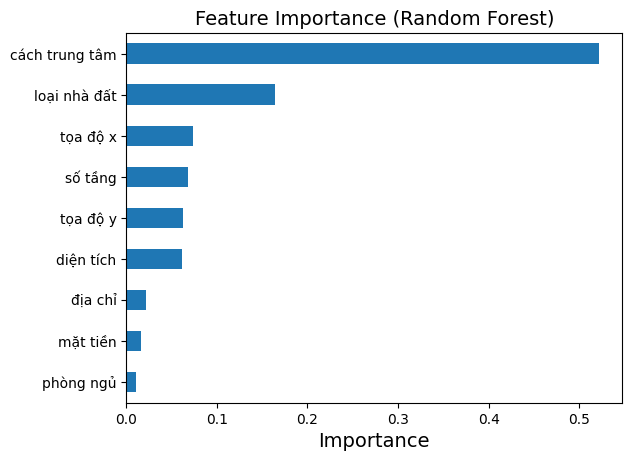

In [66]:
importance.sort_values().plot(kind="barh")
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.show()

## Load model to test

In [67]:
pipeline = jb.load("RandomForestRegressor.pkl")

median = pipeline.named_steps['imputer'].statistics_
model = pipeline.named_steps['model']

median_series = pd.Series(median, index=X_train.columns)

In [68]:
print(X_train.columns)

Index(['loại nhà đất', 'địa chỉ', 'diện tích', 'mặt tiền', 'phòng ngủ',
       'tọa độ x', 'tọa độ y', 'số tầng', 'cách trung tâm'],
      dtype='object')


In [69]:
# {"loại nhà đất": 0, "địa chỉ": 2, "giá": 9500.0, "diện tích": 80.0, "giá/m2": 118.75, "mặt tiền": null, "phòng ngủ": 2, "pháp lý": 1, "tọa độ": null, 
# "tọa độ x": 10795419054.8442, "tọa độ y": 106719977458.315, "số tầng": null}


test_data = pd.DataFrame({
    'loại nhà đất': [0],
    'địa chỉ': [2],
    'diện tích': [80],
    'mặt tiền': [None],
    'phòng ngủ': [2],
    # 'pháp lý': [1],
    'tọa độ x': [10795419054.8442 / 1000000000],
    'tọa độ y': [106719977458.315 / 1000000000],
    'số tầng': [None]
})

test_data["cách trung tâm"] = haversine(
    test_data["tọa độ x"],
    test_data["tọa độ y"],
    lat,
    lon
)
# fill missing values with median
test_data.fillna(median_series, inplace=True)

# print(test_data)
# 10.7795105160091,106.624395422216
predicted_price_per_m2 = np.exp(model.predict(test_data))
print(f"Giá dự đoán cho nhà đất: {predicted_price_per_m2[0]:.5f} triệu/m2")
print(f"Giá dự đoán cho nhà đất: {predicted_price_per_m2[0] * np.exp(test_data['diện tích'][0]):.5f} triệu")

Giá dự đoán cho nhà đất: 114.35678 triệu/m2
Giá dự đoán cho nhà đất: 6336077522981678465386284690285002752.00000 triệu


C:\Users\huy\AppData\Local\Temp\ipykernel_8784\1693592102.py:24: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_data.fillna(median_series, inplace=True)
C:\Users\huy\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


## Train thêm model 
LinearRegression, DecisionTree, KNearestNeightbor, XGBoost

In [70]:
# Chạy thêm các model: LinearRegression, DecisionTree, KNearestNeightbor, XGBoost

import joblib
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.cluster import KMeans
from xgboost import XGBRegressor

# Thêm lưu model trong m
pipeline_list = [
    Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", LinearRegression())
    ]),
    Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", DecisionTreeRegressor(random_state=42))
    ]),
    Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", KNeighborsRegressor())
    ]),
    Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", XGBRegressor(random_state=42))
    ])
]
models = {}


for pipe in pipeline_list:
    # train
    pipe.fit(X_train, y_train)

    # lấy tên model
    model_name = pipe.named_steps["model"].__class__.__name__

    # lưu model
    joblib.dump(pipe, f"{model_name}.pkl")
    models[model_name] = pipe
    print(f"Saved {model_name}.pkl")


Saved LinearRegression.pkl
Saved DecisionTreeRegressor.pkl
Saved KNeighborsRegressor.pkl
Saved XGBRegressor.pkl


In [71]:
def evaluate_model(model, X_test, y_test):
    pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    return rmse, mae, r2

for model_name, model in models.items():
    rmse, mae, r2 = evaluate_model(model.named_steps["model"], X_test, y_test)
    print(f"{model_name} - RMSE: {rmse:.2f}, MAE: {mae:.2f}, R2: {r2:.2f}")


pipeline = jb.load("RandomForestRegressor.pkl")
rmse, mae, r2 = evaluate_model(pipeline.named_steps["model"], X_test, y_test)

print(f"RandomForestRegressor - RMSE: {rmse:.2f}, MAE: {mae:.2f}, R2: {r2:.2f}")


LinearRegression - RMSE: 0.55, MAE: 0.39, R2: 0.45
DecisionTreeRegressor - RMSE: 0.44, MAE: 0.28, R2: 0.64
KNeighborsRegressor - RMSE: 0.50, MAE: 0.32, R2: 0.54
XGBRegressor - RMSE: 0.37, MAE: 0.23, R2: 0.75


C:\Users\huy\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
C:\Users\huy\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
C:\Users\huy\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but KNeighborsRegressor was fitted without feature names
  warnings.warn(


RandomForestRegressor - RMSE: 0.35, MAE: 0.22, R2: 0.78


C:\Users\huy\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


| Mô hình                 | RMSE | MAE  | R²   |
| ----------------------- | ---- | ---- | ---- |
| Linear Regression       | 0.59 | 0.41 | 0.38 |
| Decision Tree Regressor | 0.40 | 0.27 | 0.71 |
| KNeighbors Regressor    | 0.52 | 0.35 | 0.51 |
| XGBoost Regressor       | 0.35 | 0.24 | 0.78 |
| Random Forest Regressor | 0.33 | 0.22 | 0.81 |


## Phân tích kết quả
- Kết quả thực nghiệm cho thấy mô hình Linear Regression cho hiệu quả thấp nhất với hệ số R² chỉ đạt 0.22. Điều này cho thấy mối quan hệ giữa các thuộc tính bất động sản và giá bán không mang tính tuyến tính đơn giản.

- Mô hình Decision Tree Regressor cải thiện đáng kể kết quả so với Linear Regression với R² đạt 0.69. Điều này cho thấy các mô hình dựa trên cây có khả năng nắm bắt các mối quan hệ phi tuyến trong dữ liệu tốt hơn.

- Mô hình K-Nearest Neighbors cho kết quả trung bình với R² đạt 0.49. Phương pháp này phụ thuộc nhiều vào khoảng cách giữa các điểm dữ liệu nên dễ bị ảnh hưởng bởi nhiễu và sự phân bố không đồng đều của dữ liệu.

- Hai mô hình cho kết quả tốt nhất là Random Forest Regressor và XGBoost Regressor, với R² đạt khoảng 0.78 và sai số RMSE thấp nhất. Điều này cho thấy các mô hình ensemble dựa trên nhiều cây quyết định có khả năng học được các mối quan hệ phức tạp trong dữ liệu bất động sản.

Dựa trên kết quả thực nghiệm, mô hình Random Forest Regressor được lựa chọn làm mô hình chính của hệ thống.

Lý do lựa chọn Random Forest bao gồm:

+ Khả năng dự đoán chính xác với sai số thấp

+ Ít bị overfitting hơn so với Decision Tree đơn lẻ

+ Hoạt động ổn định với dữ liệu có nhiều đặc trưng khác nhau

+ Cho phép phân tích mức độ quan trọng của các đặc trưng (feature importance)

Mô hình sau khi huấn luyện được lưu lại dưới dạng file .pkl để phục vụ cho việc tích hợp vào hệ thống web trong bước triển khai tiếp theo.

## FINE-TURNING

In [72]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    "n_estimators": [100,200,300],
    "max_depth": [10,20,30,None],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4]
}

rf = RandomForestRegressor()

search = RandomizedSearchCV(
    rf,
    param_grid,
    n_iter=20,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_

In [73]:
rmse, mae, r2 = evaluate_model(best_model, X_test, y_test)
print(f"Best RandomForestRegressor - RMSE: {rmse:.2f}, MAE: {mae:.2f}, R2: {r2:.2f}")

Best RandomForestRegressor - RMSE: 0.35, MAE: 0.22, R2: 0.78


In [74]:
search.best_params_

{'n_estimators': 300,
 'min_samples_split': 5,
 'min_samples_leaf': 2,
 'max_depth': None}

In [75]:
jb.dump(best_model, "Best_RandomForestRegressor.pkl")

['Best_RandomForestRegressor.pkl']

In [76]:
import joblib as jb
import numpy as np
import pandas as pd

pipeline = jb.load("RandomForestRegressor.pkl")
median = pipeline.named_steps['imputer'].statistics_
model = pipeline.named_steps['model']

X_train_columns = ['loại nhà đất', 'địa chỉ', 'diện tích', 'mặt tiền', 'phòng ngủ',
       'tọa độ x', 'tọa độ y', 'số tầng', 'distance_center_km']
median_series = pd.Series(median, index=X_train_columns)

lat = 10.7769
lon = 106.7009

def haversine(lat1, lon1, lat2, lon2):
    R = 6371

    lat1, lon1, lat2, lon2 = map(
        np.radians, [lat1, lon1, lat2, lon2]
    )

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + \
        np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2

    c = 2*np.arcsin(np.sqrt(a))

    return R*c

# {"loại nhà đất": 0, "địa chỉ": 2, "giá": 9500.0, "diện tích": 80.0, "giá/m2": 118.75, "mặt tiền": null, "phòng ngủ": 2, "pháp lý": 1, "tọa độ": null, 
# "tọa độ x": 10795419054.8442, "tọa độ y": 106719977458.315, "số tầng": null}



test_data = pd.DataFrame({
    'loại nhà đất': [0],
    'địa chỉ': [2],
    'diện tích': [80],
    'mặt tiền': [None],
    'phòng ngủ': [2],
    # 'pháp lý': [1],
    'tọa độ x': [10795419054.8442 / 1000000000],
    'tọa độ y': [106719977458.315 / 1000000000],
    'số tầng': [None]
})

test_data["distance_center_km"] = haversine(
    test_data["tọa độ x"],
    test_data["tọa độ y"],
    lat,
    lon
)
# fill missing values with median
test_data.fillna(median_series, inplace=True)

# print(test_data)
# 10.7795105160091,106.624395422216
predicted_price_per_m2 = np.exp(model.predict(test_data))
print(f"Giá dự đoán cho nhà đất: {predicted_price_per_m2[0]:.5f} triệu/m2")
print(f"Giá dự đoán cho nhà đất: {predicted_price_per_m2[0] * test_data['diện tích'][0]:.5f} triệu")

Giá dự đoán cho nhà đất: 114.35678 triệu/m2
Giá dự đoán cho nhà đất: 9148.54265 triệu


C:\Users\huy\AppData\Local\Temp\ipykernel_8784\136863481.py:57: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_data.fillna(median_series, inplace=True)
C:\Users\huy\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


In [77]:
for i in df.value_counts("loại nhà đất").index:
    for j in REAL_ESTATE_:
        if i == REAL_ESTATE_[j]:
            print(f"{j}: {df.value_counts('loại nhà đất')[i]}") 

nhà riêng: 5451
nhà mặt phố: 2692
căn hộ chung cư: 2404
bán đất: 1613
nhà biệt thự, liền kề: 800
